## **Arquitectura Multimodal sobre Corpus Global Unificado**

Se entrena y ajusta en este notebook el modelo multimodal sobre el corpus global unificado obtenido, aplicando diferentes técnicas de fusión (temprana, tardía mediante voto mayoritario, tardía mediante promedio, tardía mediante aproximación a regresión logística y mediante atención), seleccionando en el siguiente notebook el modelo (y por tanto, técnica de fusión) que mayor rendimiento alcance en la partición de validación global. 

### **Entrenamiento y Ajuste de Hiperparámetros**

Para la combinación de extractores seleccionada que mayor rendimiento conjunto obtienen, se entrenan a continuación las arquitecturas multimodales resultantes de combinar dichos extractores mediante las estrategias de fusión indicadas para el corpus global unificado, llevando a cabo un ajuste de hiperparámetros.
- Recordamos la combinación de extractores ganadora seleccionada:

    1. **`ResNet` + `Wav2Vec` + `RoBERTa`**

La arquitectura multimodal cuenta con los siguientes componentes:

1. **Extractores seleccionados por cada modalidad** (ya indicados).
2. **Adaptadores** independientes por cada modalidad que mapeen dichos vectores de características extraídos a un espacio latente común normalizado (constituidos por una LSTM, en el caso de audio y vídeo, + capa lineal, además de aplicar normalización, ReLU y dropout). 
3. **Estrategia de Fusión**: Fusión Temprana / Fusión Tardía mediante voto mayoritario / Fusión Tardía mediante promedio / Fusión Tardía mediante aproximación a Regresión Logística / Fusión mediante Atención.
4. **Clasificador MLP**: En el caso de la **fusión temprana**, es el mismo clasificador explicado en el anterior notebook, constituido por las siguientes capas y en este mismo orden: `BatchNorm1d` (capa de normalización), `ReLU`, `Dropout`, capa lineal de compresión, `BatchNorm1d`, `ReLU`, `Dropout` y una última capa lineal para obtener el *logit* (resultado único en crudo de la red). Para el resto de fusiones se adapta adecuadamente (en el caso de las de fusión tardía, serán MLP individuales compuestos por 2 capas lineales que obtienen los logits por cada modalidad por separado, aplicando posteriormente la fusión a nivel de decisión; mientras que para la fusión mediante atención cuenta con una primera capa de atención, seguido del mismo clasificador MLP empleado para los baselines unimodales). 



Para llevar a cabo el ajuste de hiperparámetros, se ha optado por realizar dos Grid Search secuenciales: 

* **FASE 1: GRID SEARCH de Ventanas de contexto**. Partiendo de la configuración básica para el resto de hiperparámetros (la predeterminada), vamos a realizar una primera búsqueda en rejilla para todas las combinaciones posibles de ventanas de contexto de las modalidades: 

    * **Vídeo**: `32 frames` vs `16 frames`.
    * **Audio**: `11 segundos` vs `7 segundos`.
    * **Texto**: `64 tokens` vs `32 tokens`.

De esta fase, fijamos la **combinación de ventanas de contexto** con las que mayor F1-Score Macro alcanza el modelo, superando el umbral de Recall de 0.45 para la clase de Estrés. Ante empate o valores muy ajustados en F1-Score Macro, se fija aquella configuración que obtenga el mayor **Recall** para la clase positiva (Estrés).

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**. Con las ventanas ya óptimas fijadas, se ajustará el tamaño de la red y su nivel de regularización mediante otro grid search:

    * **Red grande**: `proj_dim = 512` y `hidden_mlp = 128` vs **Red pequeña**:  `proj_dim = 256` y `hidden_mp = 64`.
    * **Dropout**: `0.5`(estándar) vs `0.3`(menor regularización, permite mayor flujo de información). 
    * **Learning Rate (`lr`)**: `1e-4` vs `5e-5` vs `1e-5`. Probamos con valores bajos ya que nuestro dataset es pequeño y desbalanceado, no conviene dar pasos grandes.


Los valores indicados para el ajuste por cada hiperparámetro se han extraído de la literatura (excepto las ventanas, extraídas del EDA). Se han limitado a una cantidad razonable para evitar la explosión combinatoria. 

Por otro lado, los hiperparámetros que hemos decidido **FIJAR** (NO los ajustamos), dejando los valores por defecto, son:
- `epochs` (**default=20**): Número máximo de epochs.
- `patience` (**default=5**): Paciencia para Early Stopping.
- `pos_weight_mult`(**default=1.0**): Multiplicador para el peso de la clase positiva.
- `batch_size` (**default=32**): Tamaño del batch. Debido a su relación directa con el Learning Rate, se ha decidido fijarlo con 32 y ajustar Learning Rate. 
- `weight_decay` (**default=1e-2**): Weight decay (Regularización L2). El valor por defecto (1e-2) es el valor óptimo indicado en la literatura para el optimizador AdamW. 
- `hidden_lstm`: Se calcula y fija de forma dinámica en los adaptadores como paso intermedio (proporcional a la entrada del backbone y al `proj_dim`) para evitar cuellos de botella en la compresión temporal.

Para estos, se dejan los valores por defecto.  


Los modelos se entrenarán y ajustarán sobre:
- Particiones *train* y *dev* (para validación) del **Dataset Global Unificado (MELD + IEMOCAP)**.

In [1]:
# Importamos las librerías necesarias:

import os
import json
import matplotlib.pyplot as plt

-----

### **1. Fusión Temprana**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"global_early_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:31<00:00, 14.46it/s, loss=0.837]


Epoch 1. Train Loss: 0.9399. Val Loss: 0.9716. Val F1 Macro: 0.5874. Val Recall Estrés: 0.7888

Nuevo mejor modelo: (F1: 0.5874) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:27<00:00, 16.26it/s, loss=0.548]


Epoch 2. Train Loss: 0.8449. Val Loss: 0.9603. Val F1 Macro: 0.6206. Val Recall Estrés: 0.7421

Nuevo mejor modelo: (F1: 0.6206) -> Guardando pesos...


...

Epoch 9. Train Loss: 0.6555. Val Loss: 1.0308. Val F1 Macro: 0.6876. Val Recall Estrés: 0.5852

Sin mejora en F1-Score. Límite: 3/5


Epoch 10/20: 100%|██████████| 453/453 [00:22<00:00, 19.71it/s, loss=0.538]


Epoch 10. Train Loss: 0.6278. Val Loss: 0.9630. Val F1 Macro: 0.6528. Val Recall Estrés: 0.7738

Sin mejora en F1-Score. Límite: 4/5


Epoch 11/20: 100%|██████████| 453/453 [00:23<00:00, 18.97it/s, loss=0.758]


Epoch 11. Train Loss: 0.6065. Val Loss: 1.0089. Val F1 Macro: 0.6749. Val Recall Estrés: 0.6742

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 11 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6911 | Recall estrés: 0.6229

CONFIGURACIÓN GANADORA: global_early_resnet32_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7087


Las ventanas con las que mayor rendimiento ha logrado el modelo son:
* **Vídeo**: 32 frames
* **Audio**: 11 segundos
* **Texto**: 64 tokens

Observamos que en todas las modalidades, el modelo entrenado con el **dataset global** mejora su rendimiento con ventanas grandes. En un primer momento, podemos pensar que se ve beneficiado al contar con más información a la entrada, y aprende relaciones más complejas de los datos de cada modalidad. 

Se fijan estas ventanas para el siguiente Grid Search.

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_early_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:31<00:00, 14.29it/s, loss=0.851]


Epoch 1. Train Loss: 0.9496. Val Loss: 0.9923. Val F1 Macro: 0.5717. Val Recall Estrés: 0.7994

Nuevo mejor modelo: (F1: 0.5717) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:31<00:00, 14.50it/s, loss=0.956]


Epoch 2. Train Loss: 0.8409. Val Loss: 0.9319. Val F1 Macro: 0.6040. Val Recall Estrés: 0.8326

Nuevo mejor modelo: (F1: 0.6040) -> Guardando pesos...


...

Epoch 13. Train Loss: 0.6839. Val Loss: 1.0205. Val F1 Macro: 0.6119. Val Recall Estrés: 0.7134

Sin mejora en F1-Score. Límite: 3/5


Epoch 14/20: 100%|██████████| 453/453 [00:26<00:00, 17.09it/s, loss=0.796]


Epoch 14. Train Loss: 0.6661. Val Loss: 1.0471. Val F1 Macro: 0.6041. Val Recall Estrés: 0.7210

Sin mejora en F1-Score. Límite: 4/5


Epoch 15/20: 100%|██████████| 453/453 [00:28<00:00, 15.67it/s, loss=0.602]


Epoch 15. Train Loss: 0.6527. Val Loss: 1.0642. Val F1 Macro: 0.6054. Val Recall Estrés: 0.6878

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 15 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
global_early_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6140 | Recall estrés: 0.6848

CONFIGURACIÓN GANADORA: global_early_resnet32_wav2vec11s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7195


El mejor modelo (F1=0.7195 | Recall=0.6003) presenta los siguientes hiperparámetros:
* **Ventanas**:
    * **Vídeo**: 32 frames
    * **Audio**: 11 segundos
    * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 512 y `hidden_mlp` = 128 (Red grande).
    * **Learning Rate**: `lr` = 5e-05
    * **Dropout**: `do` = 0.3

Destaca que el modelo, para alcanzar el mejor rendimiento en F1 Score Macro y superar el umbral de Recall, ha necesitado para ello una arquitectura mucho más grande (mayor capacidad), un dropout menor, confirmando que sí se beneficia de la sinergia multimodalidad, aprendiendo patrones y relaciones complejas entre las modalidades de entrada (gracias a la fusión temprana y a las ventanas grandes de contexto para todas las modalidades).


MEJOR CONFIGURACIÓN GLOBAL FINAL: global_early_resnet32_wav2vec11s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7195


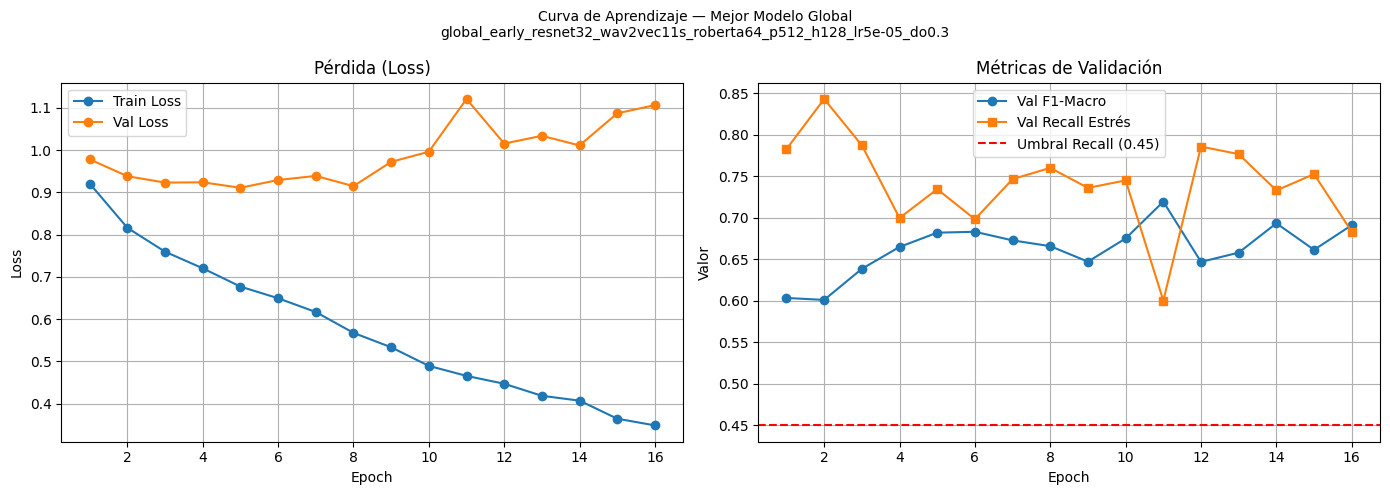

In [7]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN GLOBAL FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo Global\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_global_early.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

Se observa un claro sobreajuste (el loss en train disminuye mientras que el loss en val aumenta), algo esperable al contar con un dataset limitado en número de muestras y al contar nuestra arquitectura multimodal con varias partes (modelos preentrenados como extractores + adaptadores + posterior clasificador), pudiendo la red memorizar los datos. Lo hemos tratado con el mecanismo de parada temprana en `train.py` (además de con la función de pérdida `BCEWithLogitsLoss` con `pos_weight`, optimizador `AdamW`, dropout, DataLoader con shuffle a True para no pasar los datos a la red siempre en el mismo orden) alcanzando su valor máximo de F1-Score Macro (y menor Recall) en la epoch 11 (que es la epoch donde los pesos del modelo se guardan y salta la condición de parada temprana para las siguientes 5 épocas, deteniéndose el entrenamiento en la época 16). 

### **2. Fusión Tardía mediante voto mayoritario**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:28<00:00, 15.71it/s, loss=0.853]


Epoch 1. Train Loss: 0.9870. Val Loss: 1.0424. Val F1 Macro: 0.4935. Val Recall Estrés: 0.9080

Nuevo mejor modelo: (F1: 0.4935) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:28<00:00, 15.66it/s, loss=0.848]


Epoch 2. Train Loss: 0.9344. Val Loss: 1.0181. Val F1 Macro: 0.6673. Val Recall Estrés: 0.5490

Nuevo mejor modelo: (F1: 0.6673) -> Guardando pesos...


...

Epoch 15. Train Loss: 0.7627. Val Loss: 0.9999. Val F1 Macro: 0.5945. Val Recall Estrés: 0.8356

Sin mejora en F1-Score. Límite: 3/5


Epoch 16/20: 100%|██████████| 453/453 [00:25<00:00, 17.77it/s, loss=1.05] 


Epoch 16. Train Loss: 0.7551. Val Loss: 1.0059. Val F1 Macro: 0.6093. Val Recall Estrés: 0.7919

Sin mejora en F1-Score. Límite: 4/5


Epoch 17/20: 100%|██████████| 453/453 [00:23<00:00, 19.51it/s, loss=0.866]


Epoch 17. Train Loss: 0.7513. Val Loss: 1.0264. Val F1 Macro: 0.5918. Val Recall Estrés: 0.7873

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 17 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6104 | Recall estrés: 0.7888

CONFIGURACIÓN GANADORA: global_late_voto_resnet32_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6673


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 11 segundos
* **Texto**: 64 tokens

 * **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:28<00:00, 15.69it/s, loss=1.01] 


Epoch 1. Train Loss: 1.0000. Val Loss: 1.0535. Val F1 Macro: 0.6496. Val Recall Estrés: 0.4857

Nuevo mejor modelo: (F1: 0.6496) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:32<00:00, 13.73it/s, loss=0.878]


Epoch 2. Train Loss: 0.9397. Val Loss: 1.0117. Val F1 Macro: 0.5580. Val Recall Estrés: 0.8688

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 12. Train Loss: 0.8941. Val Loss: 1.0679. Val F1 Macro: 0.6491. Val Recall Estrés: 0.4314

Sin mejora en F1-Score. Límite: 3/5


Epoch 13/20: 100%|██████████| 453/453 [00:26<00:00, 16.90it/s, loss=0.796]


Epoch 13. Train Loss: 0.8896. Val Loss: 1.0767. Val F1 Macro: 0.6404. Val Recall Estrés: 0.4208

Sin mejora en F1-Score. Límite: 4/5


Epoch 14/20: 100%|██████████| 453/453 [00:28<00:00, 15.80it/s, loss=0.821]


Epoch 14. Train Loss: 0.8808. Val Loss: 1.0645. Val F1 Macro: 0.6483. Val Recall Estrés: 0.4449

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 14 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_voto_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6632 | Recall estrés: 0.5113

CONFIGURACIÓN GANADORA: global_late_voto_resnet32_wav2vec11s_roberta64_p256_h64_lr0.0001_do0.5
Mejor Val F1: 0.6891


El modelo que mayor rendimiento ha alcanzado (F1=0.6891 | Recall=0.5143) presenta la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 32 frames
  * **Audio**: 11 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64
  * **Learning Rate**: `lr` = 1e-4
  * **Dropout**: `do` = 0.5

Vemos que esta arquitectura mejora su rendimiento con ventanas grandes en todas las modalidades. Al ser la técnica de fusión tardía la de voto mayoritario, el voto de cada modalidad es muy importante y se tienen en cuenta todos ellos para la decisión final. Por este motivo, toman a su entrada ventanas más grandes, para tratar de extraer la información más importante, y con redes más pequeñas, actuar de embudo, evitando el sobreajuste que provocaría una red de mayor capacidad. 


MEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE VOTO: global_late_voto_resnet32_wav2vec11s_roberta64_p256_h64_lr0.0001_do0.5
Mejor Val F1: 0.6891


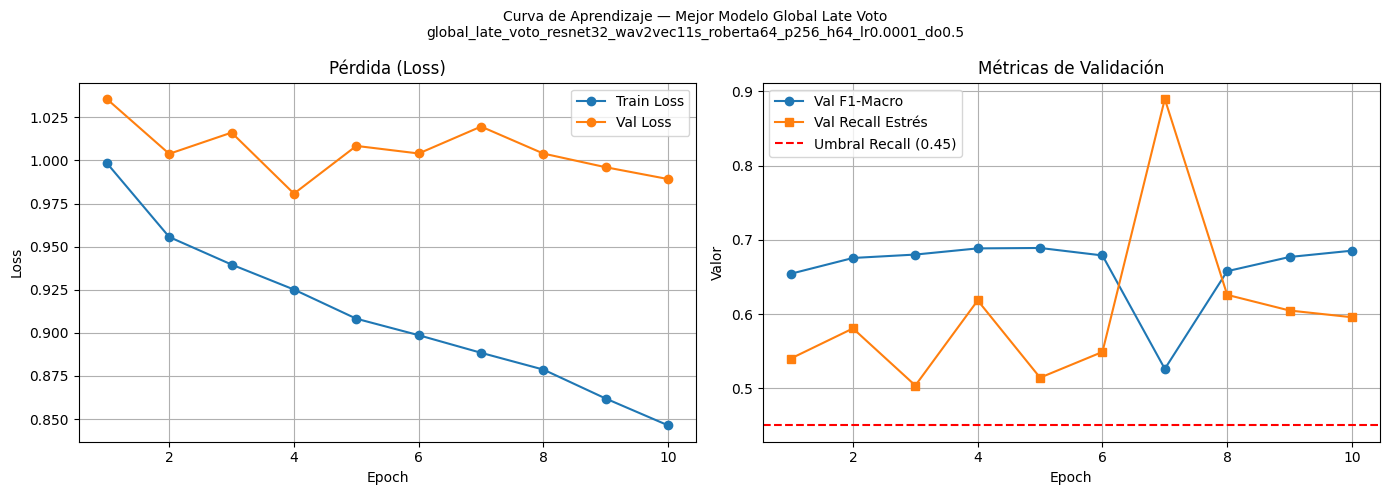

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE VOTO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo Global Late Voto\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_global_late_voto.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

Se observa un claro sobreajuste, algo también presente en las arquitecturas multimodales de fusión temprana. 

### **3. Fusión Tardía mediante promedio**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:30<00:00, 14.86it/s, loss=1.09] 


Epoch 1. Train Loss: 0.9067. Val Loss: 1.0061. Val F1 Macro: 0.5941. Val Recall Estrés: 0.7979

Nuevo mejor modelo: (F1: 0.5941) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:30<00:00, 15.04it/s, loss=0.837]


Epoch 2. Train Loss: 0.8146. Val Loss: 0.9530. Val F1 Macro: 0.6182. Val Recall Estrés: 0.7964

Nuevo mejor modelo: (F1: 0.6182) -> Guardando pesos...


...

Epoch 6. Train Loss: 0.6905. Val Loss: 0.9471. Val F1 Macro: 0.6365. Val Recall Estrés: 0.7662

Sin mejora en F1-Score. Límite: 3/5


Epoch 7/20: 100%|██████████| 453/453 [00:21<00:00, 20.80it/s, loss=1.1]  


Epoch 7. Train Loss: 0.6621. Val Loss: 0.9754. Val F1 Macro: 0.6587. Val Recall Estrés: 0.6546

Sin mejora en F1-Score. Límite: 4/5


Epoch 8/20: 100%|██████████| 453/453 [00:24<00:00, 18.25it/s, loss=0.603]


Epoch 8. Train Loss: 0.6353. Val Loss: 0.9754. Val F1 Macro: 0.6536. Val Recall Estrés: 0.6938

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 8 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6631 | Recall estrés: 0.7391

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7063


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 7 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:24<00:00, 18.67it/s, loss=0.766]


Epoch 1. Train Loss: 0.9059. Val Loss: 0.9843. Val F1 Macro: 0.5897. Val Recall Estrés: 0.8100

Nuevo mejor modelo: (F1: 0.5897) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:22<00:00, 20.21it/s, loss=0.568]


Epoch 2. Train Loss: 0.8140. Val Loss: 0.9683. Val F1 Macro: 0.6817. Val Recall Estrés: 0.5867

Nuevo mejor modelo: (F1: 0.6817) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.6371. Val Loss: 1.0288. Val F1 Macro: 0.6342. Val Recall Estrés: 0.5445

Sin mejora en F1-Score. Límite: 3/5


Epoch 19/20: 100%|██████████| 453/453 [00:19<00:00, 22.97it/s, loss=0.425]


Epoch 19. Train Loss: 0.6150. Val Loss: 1.0385. Val F1 Macro: 0.6284. Val Recall Estrés: 0.5867

Sin mejora en F1-Score. Límite: 4/5


Epoch 20/20: 100%|██████████| 453/453 [00:19<00:00, 22.76it/s, loss=0.634]


Epoch 20. Train Loss: 0.6046. Val Loss: 1.0676. Val F1 Macro: 0.6278. Val Recall Estrés: 0.5234

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 20 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_promedio_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6388 | Recall estrés: 0.5400

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_wav2vec7s_roberta64_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.7215


El modelo con mayor rendimiento (F1=0.7215 | Recall=0.5566) tiene la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 32 frames
  * **Audio**: 7 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64
  * **Learning Rate**: 1e-4
  * **Dropout**: 0.3

Esta técnica de fusión tardía logra superar a la de voto mayoritario, con ventanas de vídeo y texto también grandes, pero para audio reduce su ventana a 7 segundos. Esto podría deberse a que, para tomar la decisión, se calcula el promedio de las decisiones tomadas por cada modalidad, y en este contexto el audio podría verse "enmascarado" frente al vídeo y el texto, que son los que llevan el mayor peso en la toma de decisión, aunque esto debería revisarse con un análisis de interpretabilidad. La arquitectura de red es de una menor capacidad, igual que ocurría en el voto mayoritario. 



MEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE PROMEDIO: global_late_promedio_resnet32_wav2vec7s_roberta64_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.7215


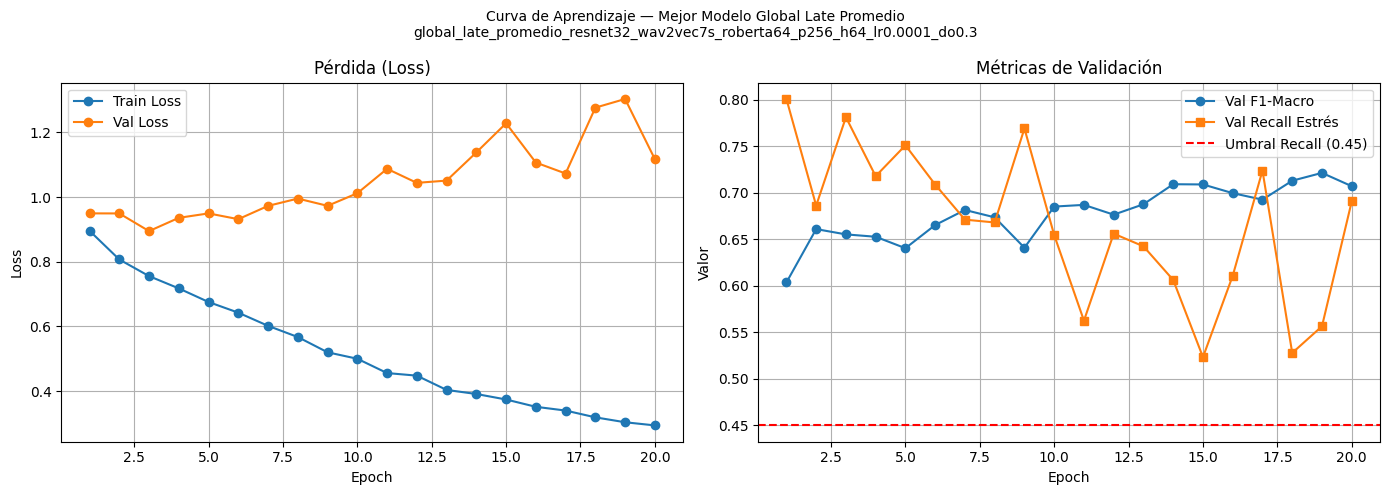

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE PROMEDIO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo Global Late Promedio\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_global_late_promedio.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **4. Fusión Tardía mediante Regresión Logística**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:36<00:00, 12.50it/s, loss=1.22] 


Epoch 1. Train Loss: 0.8980. Val Loss: 0.9319. Val F1 Macro: 0.6206. Val Recall Estrés: 0.7662

Nuevo mejor modelo: (F1: 0.6206) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:31<00:00, 14.41it/s, loss=0.838]


Epoch 2. Train Loss: 0.8042. Val Loss: 0.9398. Val F1 Macro: 0.6462. Val Recall Estrés: 0.7391

Nuevo mejor modelo: (F1: 0.6462) -> Guardando pesos...


...

Epoch 10. Train Loss: 0.5975. Val Loss: 1.0009. Val F1 Macro: 0.6971. Val Recall Estrés: 0.6063

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20: 100%|██████████| 453/453 [00:22<00:00, 20.15it/s, loss=0.366]


Epoch 11. Train Loss: 0.5722. Val Loss: 1.0888. Val F1 Macro: 0.6792. Val Recall Estrés: 0.4992

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 453/453 [00:23<00:00, 19.27it/s, loss=0.766]


Epoch 12. Train Loss: 0.5437. Val Loss: 0.9890. Val F1 Macro: 0.6738. Val Recall Estrés: 0.7029

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7085 | Recall estrés: 0.6591

CONFIGURACIÓN GANADORA: global_late_logistica_resnet16_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7094


Las ventanas óptimas son:
* **Vídeo**: 16 frames
* **Audio**: 7 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:24<00:00, 18.13it/s, loss=0.706]


Epoch 1. Train Loss: 0.9514. Val Loss: 0.9683. Val F1 Macro: 0.6723. Val Recall Estrés: 0.6003

Nuevo mejor modelo: (F1: 0.6723) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:23<00:00, 19.22it/s, loss=0.58] 


Epoch 2. Train Loss: 0.8125. Val Loss: 0.9206. Val F1 Macro: 0.6656. Val Recall Estrés: 0.7330

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 8. Train Loss: 0.8181. Val Loss: 1.1814. Val F1 Macro: 0.5676. Val Recall Estrés: 0.6621

Sin mejora en F1-Score. Límite: 3/5


Epoch 9/20: 100%|██████████| 453/453 [00:19<00:00, 22.86it/s, loss=0.742]


Epoch 9. Train Loss: 0.7934. Val Loss: 1.1826. Val F1 Macro: 0.5690. Val Recall Estrés: 0.6350

Sin mejora en F1-Score. Límite: 4/5


Epoch 10/20: 100%|██████████| 453/453 [00:24<00:00, 18.78it/s, loss=0.6]  


Epoch 10. Train Loss: 0.7739. Val Loss: 1.1627. Val F1 Macro: 0.5684. Val Recall Estrés: 0.6003

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 10 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_logistica_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.5796 | Recall estrés: 0.6365

CONFIGURACIÓN GANADORA: global_late_logistica_resnet16_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7204


El modelo que mayor rendimiento alcanza (F1=0.7204 | Recall=0.6214) tiene la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 7 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 5e-05
  * **Dropout**: `do` = 0.3

Por último, la técnica de fusión tardía mediante la aproximación a una regresión logística, reduce las ventanas de audio y vídeo, únicamente manteniendo el texto con el mayor tamaño de ventana. Recordamos que esta técnica de fusión tardía presenta una capa lineal final adicional de 3 neuronas, tras obtener los logits de cada modalidad, para aprender la fusión ponderada (que luego, con la sigmoide aplicada en la función de pérdida de `BCEWithLogitsLoss` es matemáticamente equivalente a una regresión logística). En este sentido, cada modalidad se pondera a la hora de tomar la decisión final y es en este caso donde, explícitamente la red nos está indicando que se beneficia mucho más de la información aportada por el texto a la hora de tomar la decisión, que con respecto al resto de modalidades, tomando una mayor ventana de contexto de la misma. Veremos en el próximo notebook si esta tendencia persiste para la técnica de fusión mediante atención, que es la más cercana a esta técnica de regresión logística. 


MEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE REGRESIÓN LOGÍSTICA: global_late_logistica_resnet16_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7204


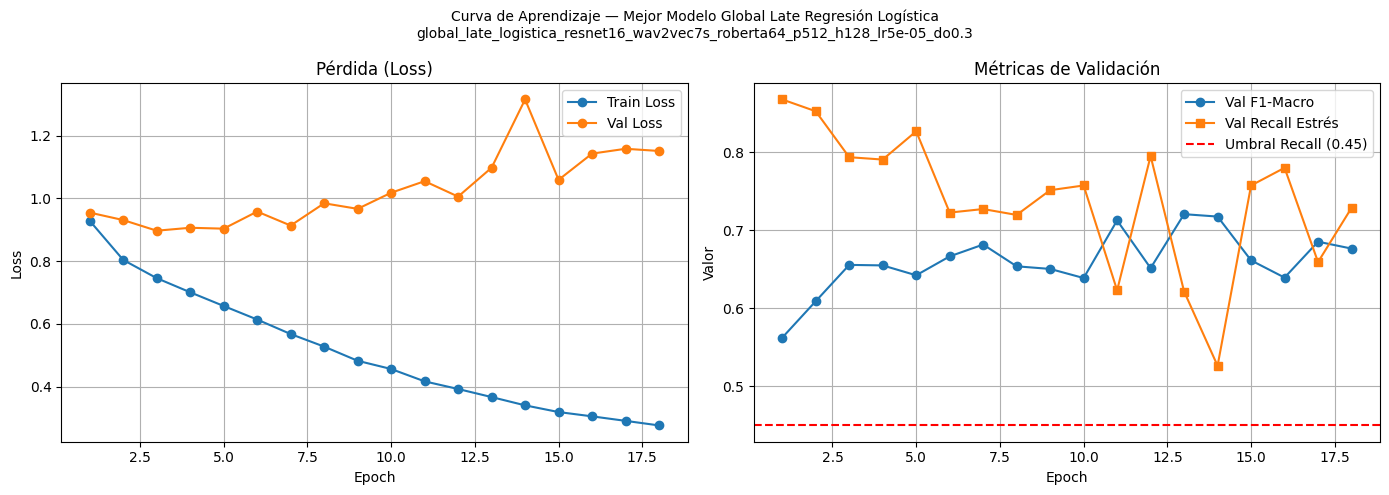

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN GLOBAL LATE MEDIANTE REGRESIÓN LOGÍSTICA: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo Global Late Regresión Logística\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_global_late_logistica.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **5. Fusión mediante Atención**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"global_attention_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:30<00:00, 14.76it/s, loss=0.646]


Epoch 1. Train Loss: 0.9091. Val Loss: 0.9287. Val F1 Macro: 0.6587. Val Recall Estrés: 0.7496

Nuevo mejor modelo: (F1: 0.6587) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:31<00:00, 14.43it/s, loss=1.7]  


Epoch 2. Train Loss: 0.8237. Val Loss: 0.9660. Val F1 Macro: 0.6170. Val Recall Estrés: 0.8160

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 12. Train Loss: 0.5946. Val Loss: 0.9677. Val F1 Macro: 0.7019. Val Recall Estrés: 0.6667

Sin mejora en F1-Score. Límite: 3/5


Epoch 13/20: 100%|██████████| 453/453 [00:21<00:00, 21.03it/s, loss=1.35] 


Epoch 13. Train Loss: 0.5626. Val Loss: 1.0524. Val F1 Macro: 0.7004. Val Recall Estrés: 0.5958

Sin mejora en F1-Score. Límite: 4/5


Epoch 14/20: 100%|██████████| 453/453 [00:21<00:00, 21.38it/s, loss=0.447]


Epoch 14. Train Loss: 0.5365. Val Loss: 1.0295. Val F1 Macro: 0.7065. Val Recall Estrés: 0.5988

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 14 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7104 | Recall estrés: 0.6953

CONFIGURACIÓN GANADORA: global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7328


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 7 segundos
* **Texto**: 32 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_attention_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:26<00:00, 16.94it/s, loss=0.507]


Epoch 1. Train Loss: 0.9112. Val Loss: 1.0233. Val F1 Macro: 0.5638. Val Recall Estrés: 0.8462

Nuevo mejor modelo: (F1: 0.5638) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:25<00:00, 17.77it/s, loss=1.34] 


Epoch 2. Train Loss: 0.8317. Val Loss: 0.9613. Val F1 Macro: 0.6077. Val Recall Estrés: 0.8296

Nuevo mejor modelo: (F1: 0.6077) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.5696. Val Loss: 1.0145. Val F1 Macro: 0.6101. Val Recall Estrés: 0.7738

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 453/453 [00:25<00:00, 18.08it/s, loss=0.564]


Epoch 19. Train Loss: 0.5532. Val Loss: 1.0308. Val F1 Macro: 0.6156. Val Recall Estrés: 0.7798

Sin mejora en F1-Score. Límite: 3/5


Epoch 20/20: 100%|██████████| 453/453 [00:19<00:00, 22.70it/s, loss=0.485]


Epoch 20. Train Loss: 0.5297. Val Loss: 1.0593. Val F1 Macro: 0.6055. Val Recall Estrés: 0.7587

Sin mejora en F1-Score. Límite: 4/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.json
global_attention_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.6619 | Recall estrés: 0.7089

CONFIGURACIÓN GANADORA: global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7238


El mejor modelo (F1=0.7238 | Recall=0.6802) presenta la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 32 frames
  * **Audio**: 7 segundos
  * **Texto**: 32 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 5e-05
  * **Dropout**: `do` = 0.3

Observamos la misma tendencia que en los modelos de fusión tardía, y es que los modelos logran mayor rendimiento reduciendo la ventana de audio a 7 segundos. Esto puede deberse a que los modelos extraen información específica del audio para la tarea en fragmentos cortos, al igual que ocurre para el texto en este modelo, al contrario que ocurre en vídeo, que necesita de una ventana mayor a la entrada. 

Para el mecanismo de fusión mediante atención, la red permite aprender relaciones complejas entre las modalidades, y por ese se beneficia al tener una mayor capacidad. 


MEJOR CONFIGURACIÓN GLOBAL FINAL: global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7238


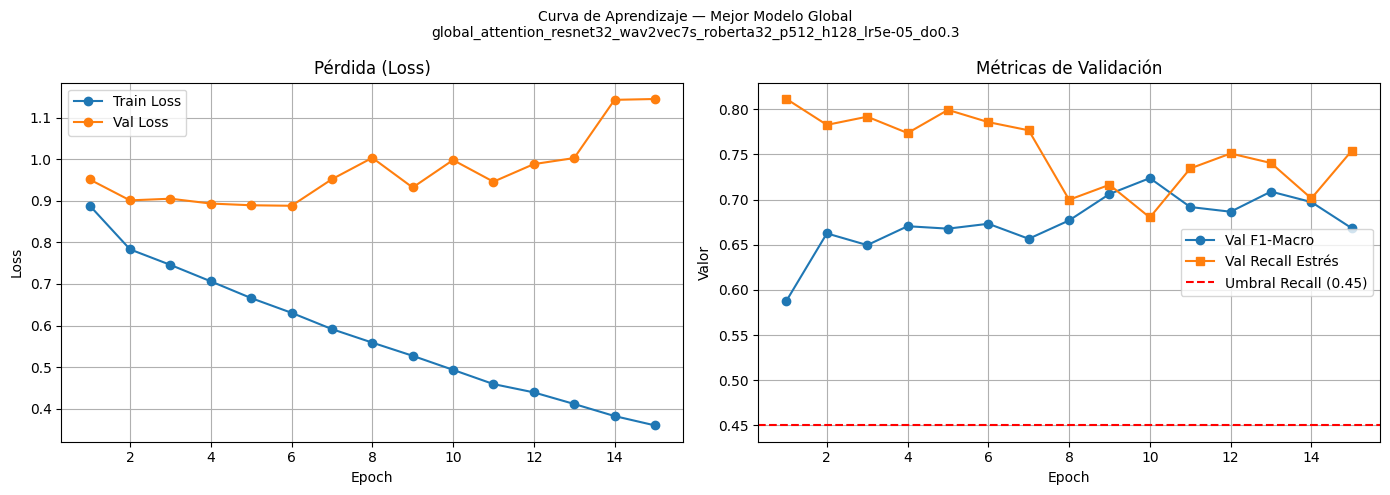

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN GLOBAL FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo Global\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_global_attention.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

Observamos también el sobreajuste presente en los modelos de fusión temprana y tardía. 